# m-mode solving of a drift scan

`limTOD.mmode` turns the time-ordered data of a single-dish drift scan into m-mode spectra. The method, in one block:

<table style="border-collapse:collapse; font-size:105%; margin:12px 0">
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap"><b>calibrated TOD</b> &nbsp;$d(\nu,t)$</td>
    <td style="padding:6px 10px; color:#666">Earth rotation makes it a Fourier series in sidereal time:
    $d(\nu,t)=\sum_m d_m(\nu)\,e^{im(t-t_{\rm ref})}$</td></tr>
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap">↓ &nbsp;<b>smooth along LST</b><br>
    <span style="font-weight:normal; color:#666; font-size:90%">(effectively a low-delay-mode-pass filter)</span></td>
    <td style="padding:6px 10px; color:#666">the <b>low m-modes are spectrally smooth</b>, the high ones are not; a kernel $k$ with transfer
    $K(m)=\sum_j k_j e^{-im\tau_j}$ passes the low $m$ and <b>suppresses the high</b>: on the smoothed data the truncated system is exact up to $K(m>M)\,d_m$.</td></tr>
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap">↓ &nbsp;<b>low-m linear system</b></td>
    <td style="padding:6px 10px; color:#666">on the smoothed data the truncated model holds:
    $y_s(t_i,\nu)=\sum_{m\le M}K(m)\,d_m(\nu)\,e^{imt_i}$, linear in the unknowns
    $[d_0,\ \mathrm{Re}\,d_1,\ \mathrm{Im}\,d_1,\dots]$</td></tr>
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap">↓ &nbsp;<b>smooth spectra, few parameters</b></td>
    <td style="padding:6px 10px; color:#666">each $d_m(\nu)$ is smooth in frequency, so it is carried by a low-order log-polynomial or spline with
    $P \ll N_\nu$ coefficients; channels outnumber parameters and the system is <b>overdetermined</b></td></tr>
<tr><td style="padding:6px 14px; border-left:4px solid #2f6f8f; white-space:nowrap">↓ &nbsp;<b>solve, with errors</b></td>
    <td style="padding:6px 10px; color:#666">least squares per channel, then per mode; noise through the smoothed covariance,
    conditioning of the design, a bound on what the suppressed modes still leak</td></tr>
</table>

Formalism: Zhang, *M-mode RIME explicit in beam, fringe and sky modes* ([note](https://zh-zhang.com/myNotes/MmodeNote.pdf),
eqns 13–14) with the fringe set to unity. The design study behind this solver — beam and sky harmonics, the resulting
$d_m(\nu)$, the smoothing filter, solvability against LST coverage — is the
**[RHINO Drift-Scan m-Modes explorer](https://claude.ai/artifact/7Ra9SBXBtvLMA27o9t3Z6T)** (private link).

Below: the beam and its chromaticity, the simulated scan, and what the solver returns — the spectra, how smooth the
$m=0$ mode is, and how precisely it is recovered with no beam model and no sky model. N$_{\rm side}$ = 32,
31 channels at 1 MHz over 55–85 MHz, 240 s cadence; the simulation takes about fifteen minutes.

In [1]:
import os, warnings, time
os.environ["TQDM_DISABLE"] = "1"          # limTOD's per-sample progress bars
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from limTOD import TODSim, GDSM_sky_model, example_symm_beam_map
from limTOD import mmode

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.titlesize": 10.5})
FREQS = np.arange(55.0, 86.0, 1.0)         # MHz, 31 channels
NU_REF = 70.0
NSIDE = 32
JBO = dict(ant_latitude_deg=53.23625, ant_longitude_deg=-2.30744, ant_height_m=80.0)
COLORS = plt.cm.viridis(np.linspace(0, 0.9, FREQS.size))
SHOW = range(0, FREQS.size, 6)              # channels drawn in the per-channel plots

def card(title, body, color="#2f6f8f"):
    display(HTML(f'<div style="border-left:6px solid {color}; background:#f4f6f8; padding:12px 18px; margin:10px 0; '
                 f'font-size:110%"><b style="font-size:115%">{title}</b><br>{body}</div>'))

## The beam, and its chromaticity

A Gaussian stands in for the horn, with the width scaling as a horn's does, FWHM $= 30^\circ\times(70\,{\rm MHz}/\nu)$:
38° wide at the bottom of the band, 25° at the top. That frequency dependence is what the m-modes carry besides the sky's own spectrum.

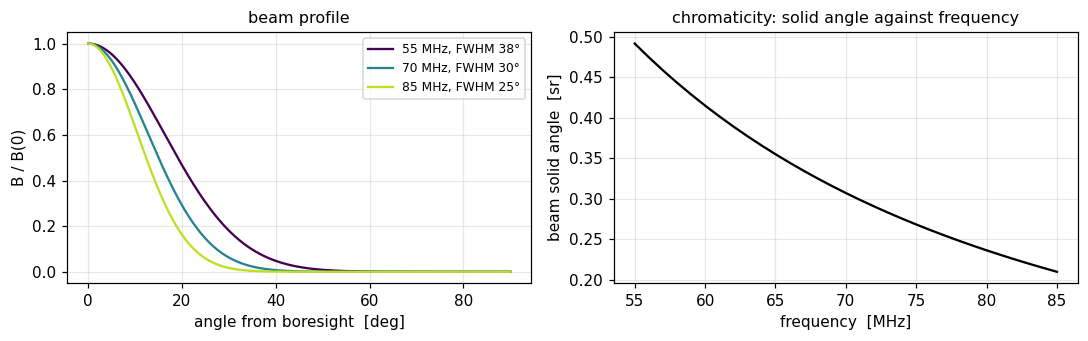

In [2]:
def fwhm_deg(freq):
    return 30.0 * 70.0 / freq

def beam_func(freq, nside):
    return example_symm_beam_map(freq=freq, nside=nside, FWHM=fwhm_deg(freq))

theta = np.linspace(0, 90, 400)
def solid_angle(f):
    b = beam_func(f, NSIDE)
    return (b / b.max()).sum() * hp.nside2pixarea(NSIDE)      # the maps are unit-sum; peak-normalise for the solid angle
omega = np.array([solid_angle(f) for f in FREQS])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for f, c in ((55, COLORS[0]), (70, COLORS[15]), (85, COLORS[30])):
    axes[0].plot(theta, np.exp(-4 * np.log(2) * (theta / fwhm_deg(f)) ** 2), color=c, label=f"{f} MHz, FWHM {fwhm_deg(f):.0f}°")
axes[0].set(xlabel="angle from boresight  [deg]", ylabel="B / B(0)", title="beam profile"); axes[0].legend(fontsize=8)
axes[1].plot(FREQS, omega, "k-")
axes[1].set(xlabel="frequency  [MHz]", ylabel="beam solid angle  [sr]", title="chromaticity: solid angle against frequency")
plt.tight_layout()

## The simulated scan

`TODSim` at Jodrell Bank, zenith pointing, GDSM sky — a foreground-only sky, no cosmological signal injected. One full
sidereal day at a cadence chosen so the last sample lands exactly one cadence before the first: `LSTWindow` recognises
the scan as **closed**, which is what makes the modes orthogonal.

simulated (359, 31) in 710 s
closed: True   samples: 359   cadence: 1.0028 deg   coverage: 1.000


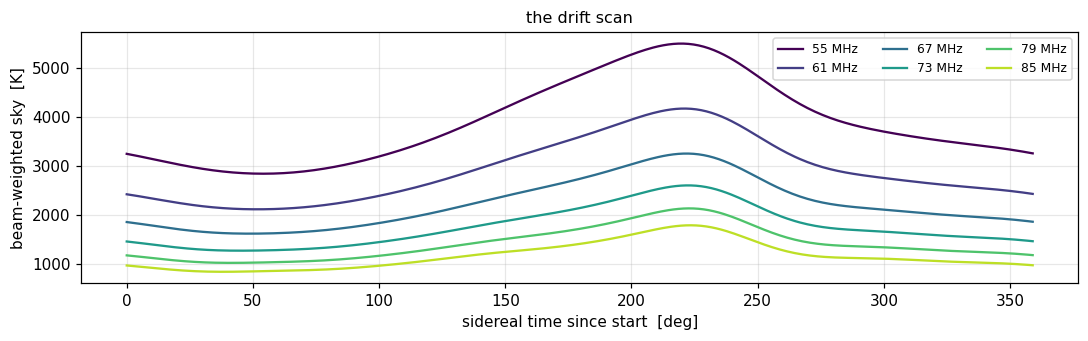

In [3]:
sim = TODSim(**JBO, beam_func=beam_func, sky_func=GDSM_sky_model, beam_nside=NSIDE, sky_nside=NSIDE)

SIDEREAL_DAY = 86164.0905                 # s
N_T = 359                                 # samples: 240 s cadence, closes the circle
CADENCE_S = SIDEREAL_DAY / N_T
t_list = np.arange(N_T) * CADENCE_S

t0 = time.time()
tod_sky, lst = sim.simulate_sky_TOD(FREQS, t_list, np.zeros(N_T), 90.0, return_LSTs=True)
tod_sky = tod_sky.T                       # (n_time, n_freq), the layout mmode expects
print(f"simulated {tod_sky.shape} in {time.time()-t0:.0f} s")

window = mmode.LSTWindow(lst, t_ref_deg=lst[0])
print(f"closed: {window.closed}   samples: {window.n}   cadence: {window.cadence_deg:.4f} deg   coverage: {window.coverage:.3f}")
assert window.closed
sky_mono = np.array([GDSM_sky_model(freq=f, nside=NSIDE).mean() for f in FREQS])     # the sky's own monopole

dt_deg = np.unwrap(np.deg2rad(lst)) * 180 / np.pi - lst[0]
fig, ax = plt.subplots(figsize=(10, 3.2))
for j in SHOW:
    ax.plot(dt_deg, tod_sky[:, j], color=COLORS[j], label=f"{FREQS[j]:.0f} MHz")
ax.set(xlabel="sidereal time since start  [deg]", ylabel="beam-weighted sky  [K]", title="the drift scan"); ax.legend(fontsize=8, ncol=3)
plt.tight_layout()

## What the solver returns

### The m-mode spectra: low modes smooth, high modes not

On the closed scan every mode up to $M=40$ is determined (`cond` ≈ 1); this noiseless solve is the **truth** for what
follows. Left: the mode ladder at a few frequencies. Middle: the low modes, $\mathrm{Re}$ and $\mathrm{Im}$ of $d_{1,2,3}(\nu)$.
Right: the higher modes, each divided by its own largest amplitude so they share an axis. Beyond $m\approx15$ this
simulation's modes sit at its pixelisation floor, marked on the ladder, so those are not drawn.

cond = 1.000   time-series residual rms 0.021 K   high-m floor 0.53 mK


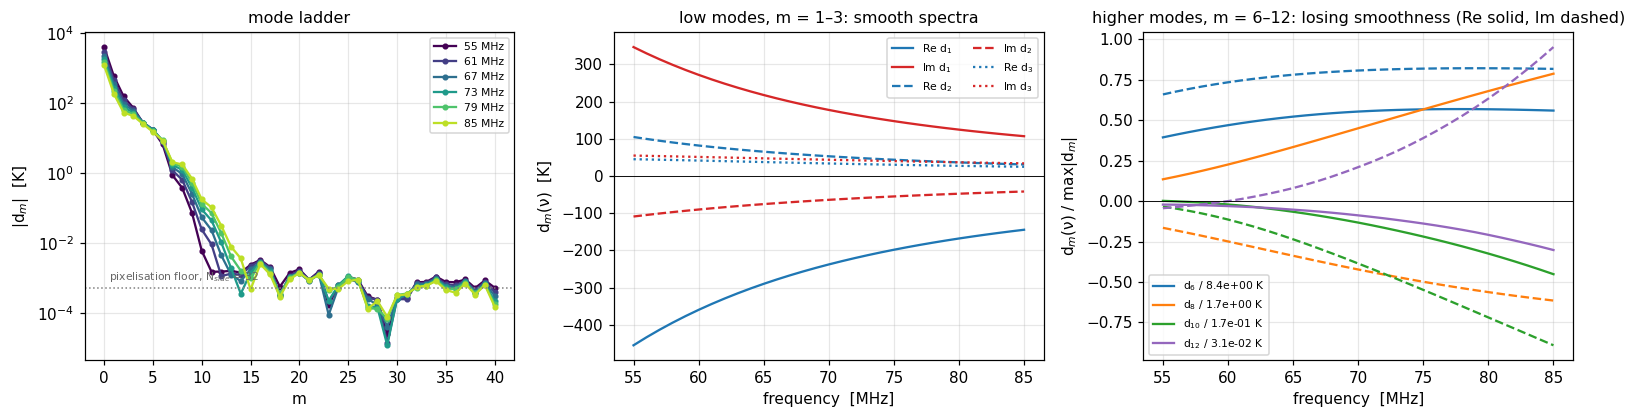

In [4]:
M_ALL = 40
truth = mmode.solve(tod_sky, window, m_trunc=M_ALL)
d_true = truth.modes                                   # (n_freq, M+1) complex
d0_true = d_true[:, 0].real
resid_m0 = d0_true - sky_mono                          # the residual m = 0 term
j70 = int(np.argmin(np.abs(FREQS - NU_REF)))
m_axis = np.arange(M_ALL + 1)
floor = np.median(np.abs(d_true[:, 25:]))              # |d_m| at high m: the simulation's discretisation level
print(f"cond = {truth.cond:.3f}   time-series residual rms {truth.residual_rms.mean():.3f} K   high-m floor {floor*1e3:.2f} mK")

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.9))
ax = axes[0]
for j in SHOW:
    ax.semilogy(m_axis, np.abs(d_true[j]), ".-", color=COLORS[j], label=f"{FREQS[j]:.0f} MHz")
ax.axhline(floor, color="0.5", ls=":", lw=1); ax.text(0.5, floor * 1.6, f"pixelisation floor, N$_{{side}}$ = {NSIDE}", fontsize=7, color="0.4")
ax.set(xlabel="m", ylabel="|d$_m$|  [K]", title="mode ladder"); ax.legend(fontsize=7)
ax = axes[1]
for mm, ls in ((1, "-"), (2, "--"), (3, ":")):
    ax.plot(FREQS, d_true[:, mm].real, ls, color="C0", label=f"Re d$_{mm}$")
    ax.plot(FREQS, d_true[:, mm].imag, ls, color="C3", label=f"Im d$_{mm}$")
ax.axhline(0, color="k", lw=0.6); ax.set(xlabel="frequency  [MHz]", ylabel="d$_m$(ν)  [K]", title="low modes, m = 1–3: smooth spectra"); ax.legend(fontsize=7, ncol=2)
ax = axes[2]
for mm, c in ((6, "C0"), (8, "C1"), (10, "C2"), (12, "C4")):
    sc = np.abs(d_true[:, mm]).max()
    ax.plot(FREQS, d_true[:, mm].real / sc, "-", color=c, label=f"d$_{{{mm}}}$ / {sc:.1e} K")
    ax.plot(FREQS, d_true[:, mm].imag / sc, "--", color=c)
ax.axhline(0, color="k", lw=0.6); ax.set(xlabel="frequency  [MHz]", ylabel="d$_m$(ν) / max|d$_m$|", title="higher modes, m = 6–12: losing smoothness (Re solid, Im dashed)"); ax.legend(fontsize=7)
plt.tight_layout()

### How smooth is the $m=0$ mode?

The $m=0$ mode is **not** the monopole but

$$d_0(\nu)=\underbrace{B_{00}T_{00}(\nu)}_{\langle T\rangle(\nu),\ \text{no beam}}+\underbrace{\sum_{\ell\ge1}T_{\ell0}(\nu)B_{\ell0}(\nu)}_{\text{residual }m=0:\ \text{all the beam chromaticity}}$$

— $B_{00}=1/\sqrt{4\pi}$ by the normalisation, so the first term is the sky's mean temperature and carries no beam;
the residual is where the beam's frequency dependence lives. The drift scan measures only their sum. A log-polynomial of
order $N$, $\log d_0=\sum_{k=0}^{N}a_k[\log(\nu/\nu_{\rm ref})]^k$ ($N+1$ coefficients), is fitted to the noiseless $m=0$ mode
of this foreground-only sky. Left: the mode and its two parts. Middle: the residual of an order-4 polynomial fit to every
mode, relative to the mode's size. Right: the fit residual of the $m=0$ mode by order.

at 70 MHz: d_0 = 1964.0 K = monopole 2757.6 K + residual -793.7 K (-40.4%)
rms residual [mK]                   order 2  order 3  order 4  order 5  order 6  order 8
d_0, the m = 0 mode                 3849.25    55.78     2.84     1.43     0.61     0.36
  its monopole part <T>             5327.09     5.81     2.09     0.49     0.36     0.37
  its residual part (linear fit)     553.34   400.80    62.82     3.70     0.84     0.40


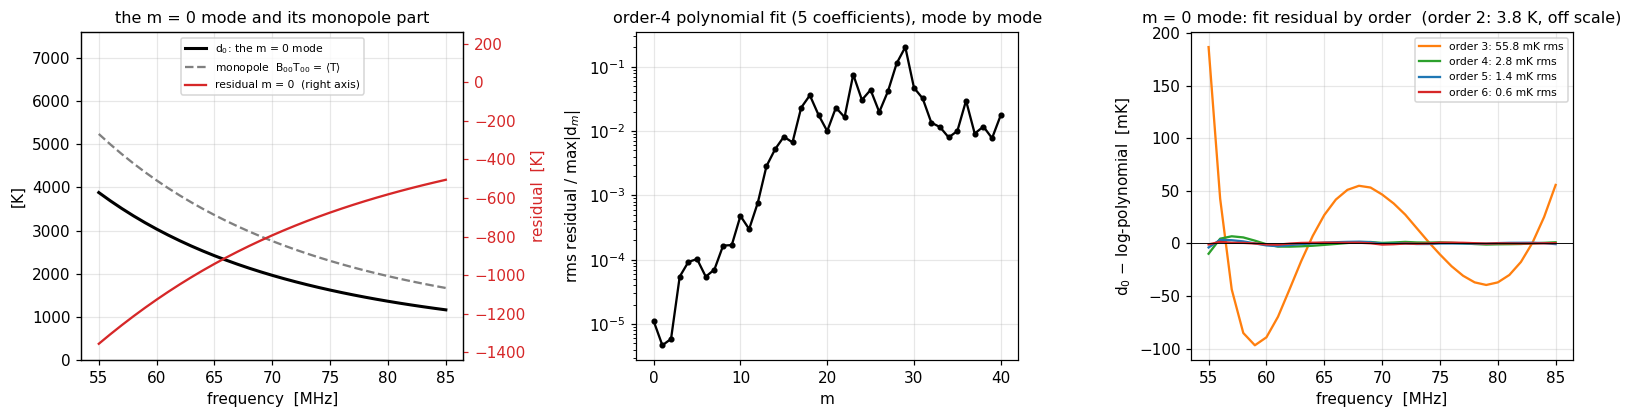

In [5]:
x = np.log(FREQS / NU_REF)
def fit_resid(y, order, log_space=True):
    yy = np.log(y) if log_space else y
    V = np.vander(x, order + 1, increasing=True)
    fit = V @ np.linalg.lstsq(V, yy, rcond=None)[0]
    return (y - np.exp(fit)) if log_space else (y - fit)
def rel_resid(m, order=4):
    # rms residual of an order-`order` polynomial fit to Re and Im of d_m, relative to max |d_m|
    z = d_true[:, m]; scale = np.abs(z).max()
    r = np.hypot(np.std(fit_resid(z.real, order, False)), np.std(fit_resid(z.imag, order, False)))
    return r / scale

orders = [2, 3, 4, 5, 6, 8]
rows = {"d_0, the m = 0 mode": [np.std(fit_resid(d0_true, n)) for n in orders],
        "  its monopole part <T>": [np.std(fit_resid(sky_mono, n)) for n in orders],
        "  its residual part (linear fit)": [np.std(fit_resid(resid_m0, n, False)) for n in orders]}
print(f"at 70 MHz: d_0 = {d0_true[j70]:.1f} K = monopole {sky_mono[j70]:.1f} K + residual {resid_m0[j70]:+.1f} K "
      f"({100 * resid_m0[j70] / d0_true[j70]:+.1f}%)")
print(f"{'rms residual [mK]':34s}" + "".join(f"{'order '+str(n):>9s}" for n in orders))
for k, v in rows.items():
    print(f"{k:34s}" + "".join(f"{1e3 * r:9.2f}" for r in v))

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.9))
ax = axes[0]
ax.plot(FREQS, d0_true, "k-", lw=2, label="d$_0$: the m = 0 mode")
ax.plot(FREQS, sky_mono, "--", color="0.5", label="monopole  B$_{00}$T$_{00}$ = ⟨T⟩")
ax.set(xlabel="frequency  [MHz]", ylabel="[K]", title="the m = 0 mode and its monopole part")
ax.set_ylim(0, 1.45 * sky_mono.max())
ax_r = ax.twinx(); ax_r.plot(FREQS, resid_m0, "-", color="C3", label="residual m = 0  (right axis)")
ax_r.set_ylim(resid_m0.min() - 0.1 * np.ptp(resid_m0), resid_m0.max() + 0.9 * np.ptp(resid_m0))
ax_r.set_ylabel("residual  [K]", color="C3"); ax_r.tick_params(axis="y", colors="C3"); ax_r.grid(False)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax_r.get_legend_handles_labels(); ax.legend(h1 + h2, l1 + l2, fontsize=7, loc="upper center")
ax = axes[1]
rr = np.array([rel_resid(mm, 4) for mm in m_axis])
ax.semilogy(m_axis, rr, "ko-", ms=3)
ax.set(xlabel="m", ylabel="rms residual / max|d$_m$|", title="order-4 polynomial fit (5 coefficients), mode by mode")
ax = axes[2]
for n, c in ((3, "C1"), (4, "C2"), (5, "C0"), (6, "C3")):
    ax.plot(FREQS, 1e3 * fit_resid(d0_true, n), "-", color=c, label=f"order {n}: {1e3 * rows['d_0, the m = 0 mode'][orders.index(n)]:.1f} mK rms")
ax.axhline(0, color="k", lw=0.6)
ax.set(xlabel="frequency  [MHz]", ylabel="d$_0$ − log-polynomial  [mK]", title=f"m = 0 mode: fit residual by order  (order 2: {rows['d_0, the m = 0 mode'][0]:.1f} K, off scale)"); ax.legend(fontsize=7)
plt.tight_layout()

r3, r4, r5 = (rows["d_0, the m = 0 mode"][i] for i in (1, 2, 3))
card("The m = 0 mode of a foreground-only sky is smooth.",
     f"A log-polynomial in log(ν/{NU_REF:.0f} MHz) fits d₀(ν), which ranges over {d0_true.min():.0f}–{d0_true.max():.0f} K, to "
     f"<b>{1e3*r3:.0f} mK</b> rms with <b>4 coefficients</b> (order 3), "
     f"<b>{1e3*r4:.1f} mK</b> with <b>5</b> (order 4, {1e6*r4/d0_true.mean():.1f} ppm of the mode), "
     f"<b>{1e3*r5:.1f} mK</b> with <b>6</b> (order 5). "
     f"The monopole part alone: {1e3*rows['  its monopole part <T>'][2]:.1f} mK with 5 coefficients. "
     f"The residual bottoms out at {1e3*rows['d_0, the m = 0 mode'][-1]:.1f} mK, the level of the high-m floor of the ladder ({floor*1e3:.1f} mK): "
     f"the simulation's discretisation, not the sky.")

### How precisely is the $m=0$ mode recovered — with no beam model and no sky model?

Nothing about the beam or the sky enters the solve: a closed scan and the radiometer equation are all it takes.
The noise per sample is $\sigma(\nu)=T_{\rm sys}(\nu)/\sqrt{\Delta\nu\,\tau}$ with $T_{\rm sys}=d_0(\nu)+100$ K
(sky-dominated plus a receiver), $\Delta\nu=1$ MHz, $\tau=240$ s; on the closed scan $\sigma(d_0)=\sigma/\sqrt{N}$
with no truncation bias at all. One night is drawn and solved; bayesmith's exact posterior samples give the band.

one night: sigma per sample 133 mK at 70 MHz -> sigma(d_0) = 7.03 mK = 3.6 ppm (3.5-3.7 ppm over the band)
pull rms of the recovered d_0 over 31 channels: 0.86


nights,σ(d₀) at 70 MHz,fraction
1,7.03 mK,3.58 ppm
10,2.22 mK,1.13 ppm
30,1.28 mK,0.65 ppm
100,0.70 mK,0.36 ppm
365,0.37 mK,0.19 ppm


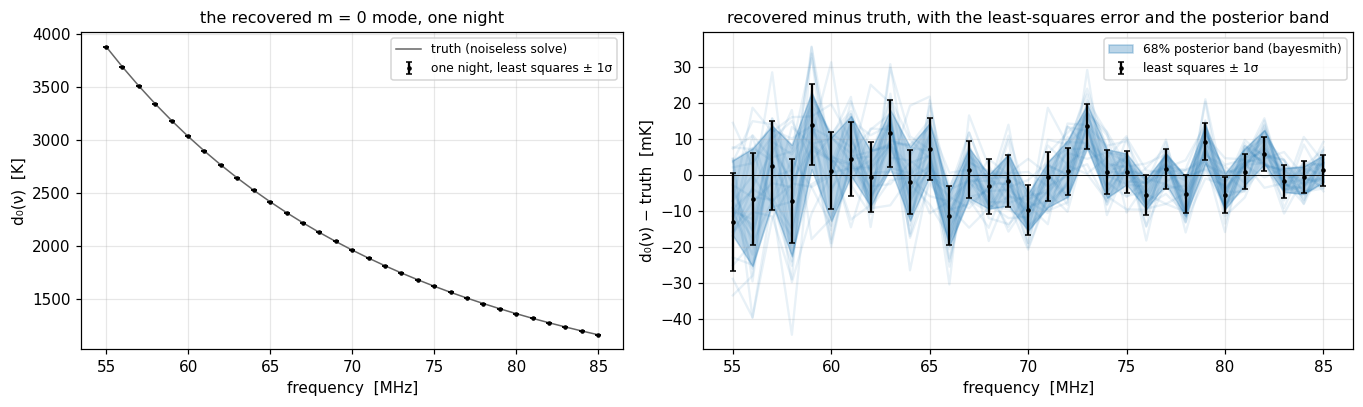

In [6]:
DNU = 1.0e6
sigma_nu = (d0_true + 100.0) / np.sqrt(DNU * CADENCE_S)             # K per sample, per channel, one night
tod_night = tod_sky + np.random.default_rng(3).normal(0, 1, tod_sky.shape) * sigma_nu[None, :]
night = mmode.solve(tod_night, window, m_trunc=M_ALL, sigma=sigma_nu)
err_ppm = 1e6 * night.std_d0() / d0_true
print(f"one night: sigma per sample {sigma_nu[j70]*1e3:.0f} mK at 70 MHz -> sigma(d_0) = {night.std_d0()[j70]*1e3:.2f} mK = {err_ppm[j70]:.1f} ppm "
      f"({err_ppm.min():.1f}-{err_ppm.max():.1f} ppm over the band)")
pull = (night.d0 - d0_true) / night.std_d0()
print(f"pull rms of the recovered d_0 over {FREQS.size} channels: {pull.std():.2f}")

nights = np.array([1, 10, 30, 100, 365])
tab = "".join(f"<tr><td style='padding:2px 14px'>{n}</td><td style='padding:2px 14px'>{night.std_d0()[j70]*1e3/np.sqrt(n):.2f} mK</td>"
              f"<td style='padding:2px 14px'>{err_ppm[j70]/np.sqrt(n):.2f} ppm</td></tr>" for n in nights)
card("The m = 0 mode is recovered with no beam model and no sky model.",
     f"One closed sidereal day (240 s samples, 1 MHz channels) gives d₀(ν) to <b>{night.std_d0()[j70]*1e3:.1f} mK</b> at 70 MHz — "
     f"<b>{err_ppm[j70]:.1f} ppm</b> ({err_ppm.min():.1f}–{err_ppm.max():.1f} ppm across the band) — with <b>no truncation bias</b>: on a closed scan every mode is exact. "
     f"The precision then improves as 1/√nights:<table style='margin-top:6px; font-size:95%'><tr><th style='padding:2px 14px'>nights</th>"
     f"<th style='padding:2px 14px'>σ(d₀) at 70 MHz</th><th style='padding:2px 14px'>fraction</th></tr>{tab}</table>"
     f"What the closed scan requires is coverage, not calibration knowledge: on a 7 h arc the same solve is degenerate (see the explorer).")

try:
    from limTOD.mmode.bayes import posterior_samples
    M_B = 12
    env = 2 * np.abs(d_true[:, :M_B + 1]).max(axis=0) + 1e-3
    post = posterior_samples(tod_night, window, mmax=M_B, envelope=env, sigma=sigma_nu, n_draws=30, seed=2)
    lo, hi = post.d0_interval(0.68)
    have_post = True
except ImportError as exc:
    print(exc); have_post = False

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), gridspec_kw={"width_ratios": [1, 1.2]})
axes[0].plot(FREQS, d0_true, "-", color="0.4", lw=1, label="truth (noiseless solve)")
axes[0].errorbar(FREQS, night.d0, yerr=night.std_d0(), fmt="k.", ms=4, capsize=2, label="one night, least squares ± 1σ")
axes[0].set(xlabel="frequency  [MHz]", ylabel="d₀(ν)  [K]", title="the recovered m = 0 mode, one night"); axes[0].legend(fontsize=8)
if have_post:
    for s in post.samples[:, :, 0].real:
        axes[1].plot(FREQS, 1e3 * (s - d0_true), "-", color="C0", alpha=0.1)
    axes[1].fill_between(FREQS, 1e3 * (lo - d0_true), 1e3 * (hi - d0_true), color="C0", alpha=0.3, label="68% posterior band (bayesmith)")
axes[1].errorbar(FREQS, 1e3 * (night.d0 - d0_true), yerr=1e3 * night.std_d0(), fmt="k.", ms=4, capsize=2, label="least squares ± 1σ")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set(xlabel="frequency  [MHz]", ylabel="d₀(ν) − truth  [mK]", title="recovered minus truth, with the least-squares error and the posterior band"); axes[1].legend(fontsize=8)
plt.tight_layout()

### Appendix: LST smoothing on a partial arc

The general case: a 300° arc, where the modes are no longer orthogonal and the modes above the truncation ($M=6$) leak
into $\hat d_0$. A DPSS kernel suppresses mode $m$ by $K(m)/K(0)$ — but on an open arc the samples within half a kernel
of either end are trimmed, and least squares on the smoothed data is least squares on that shorter window with each mode
divided by $K(m)$. Both effects are in the plugin's error budget: `std_d0` for the noise, `leakage_bound` for the worst-case
bias given an envelope of the modes above $M$ (here the closed-scan ladder). The sweep below moves the band edge from
none down to the truncation. With a ladder this steep the modes above $M=6$ are already small, and the shorter window
costs more than the suppression buys: the measured bias stays under the bound throughout, and the kernel earns its place
on scans long or closed enough that the trimming is cheap, or when gaps and coarse cadence let high modes alias.

arc 300 deg, truncation M = 6, noise 0.5 K per sample
  kernel             band edge  valid      cond  rms(d0-truth)  reported sigma  leakage bound
  none                     inf    300   9.2e+00         3.79 K          0.09 K         8.47 K
  dpss(L=41, NW=2)        17.5    260   8.5e+01        14.25 K          0.40 K        56.48 K
  dpss(L=81, NW=2)         8.9    220   1.0e+03         8.87 K          0.40 K        56.96 K
  dpss(L=121, NW=2)        5.9    180   1.7e+04         8.39 K          0.43 K        20.98 K
  dpss(L=161, NW=2)        4.5    140   5.5e+05        37.59 K          7.84 K        96.81 K


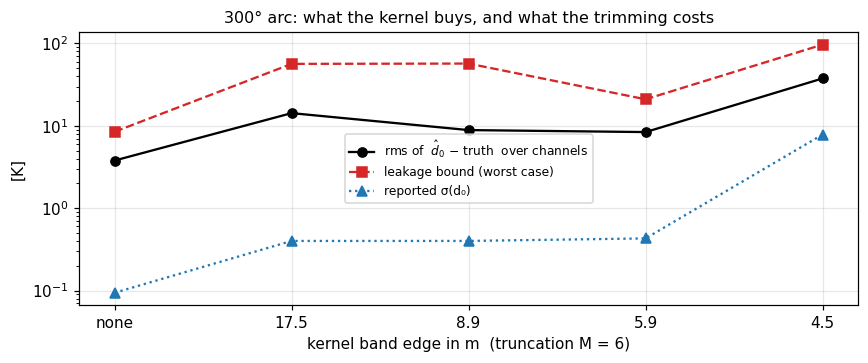

In [7]:
SIGMA = 0.5
tod_noisy = tod_sky + np.random.default_rng(1).normal(0, SIGMA, tod_sky.shape)
n300 = int(round(300.0 / window.cadence_deg)) + 1
arc300 = mmode.LSTWindow(lst[:n300], t_ref_deg=lst[0])
M_TR = 6
envelope = np.abs(d_true).max(axis=0)                     # |d_m| ladder from the closed scan, m = 0..M_ALL
kernels = [None] + [mmode.dpss_kernel(L, 2.0) for L in (41, 81, 121, 161)]
sweep = []
print(f"arc {arc300.span_deg:.0f} deg, truncation M = {M_TR}, noise {SIGMA} K per sample")
print(f"  {'kernel':18s}{'band edge':>10s}{'valid':>7s}{'cond':>10s}{'rms(d0-truth)':>15s}{'reported sigma':>16s}{'leakage bound':>15s}")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for k in kernels:
        r = mmode.solve(tod_noisy[:n300], arc300, m_trunc=M_TR, kernel=k, sigma=SIGMA)
        bound = mmode.leakage_bound(arc300, M_TR, envelope, kernel=k)
        edge = np.inf if k is None else k.band_edge(arc300, 2.0)
        err = np.sqrt(np.mean((r.d0 - d0_true) ** 2))
        sweep.append((edge, err, r.std_d0().mean(), bound, r.cond, r.n_valid))
        print(f"  {'none' if k is None else k.label:18s}{edge:10.1f}{r.n_valid:7d}{r.cond:10.1e}{err:13.2f} K{r.std_d0().mean():14.2f} K{bound:13.2f} K")
sweep = np.array(sweep)
labels = ["none"] + [f"{e:.1f}" for e in sweep[1:, 0]]
fig, ax = plt.subplots(figsize=(8, 3.4))
xpos = np.arange(len(labels))
ax.semilogy(xpos, sweep[:, 1], "ko-", label="rms of  $\\hat d_0$ − truth  over channels")
ax.semilogy(xpos, sweep[:, 3], "s--", color="C3", label="leakage bound (worst case)")
ax.semilogy(xpos, sweep[:, 2], "^:", color="C0", label="reported σ(d₀)")
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set(xlabel="kernel band edge in m  (truncation M = 6)", ylabel="[K]", title="300° arc: what the kernel buys, and what the trimming costs"); ax.legend(fontsize=8)
plt.tight_layout()